📈 REGRESIÓN LOGÍSTICA - Evitando Overfitting

📊 Datos preparados:
   Train: (2620, 9)
   Test:  (656, 9)

1️⃣  EXPERIMENTO 1: Diferentes niveles de regularización (C)

Nota: C es el inverso de la regularización
   • C bajo (ej: 0.01) = Regularización FUERTE → Menos overfitting
   • C alto (ej: 100)  = Regularización DÉBIL → Más overfitting
✅ C=  0.001 | F1 Test: 0.5396 | Gap: -0.0293
✅ C=  0.010 | F1 Test: 0.5254 | Gap: -0.0144
✅ C=  0.100 | F1 Test: 0.5203 | Gap: -0.0092
✅ C=  1.000 | F1 Test: 0.5186 | Gap: -0.0063
✅ C= 10.000 | F1 Test: 0.5186 | Gap: -0.0063
✅ C=100.000 | F1 Test: 0.5186 | Gap: -0.0063

2️⃣  EXPERIMENTO 2: Tipos de penalización

Nota sobre penalizaciones:
   • L2 (Ridge):     Reduce todos los coeficientes proporcionalmente
   • L1 (Lasso):     Puede llevar coeficientes a exactamente 0
   • Elasticnet:     Combinación de L1 y L2
✅ l2           | F1 Test: 0.5186 | Gap: -0.0063
✅ l1           | F1 Test: 0.5261 | Gap: -0.0147
✅ elasticnet   | F1 Test: 0.5186 | Gap: -0.00

C:\Users\nesto\AppData\Local\Temp\ipykernel_29280\1839296211.py:374: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([cv_scores], labels=['LR'])



✅ Gráfica guardada: 'logistic_regression_analysis.png'

💾 GUARDANDO MODELO

✅ Archivos guardados:
   • modelo_lr_final.pkl
   • imputer_lr_final.pkl
   • scaler_lr_final.pkl

✨ RESUMEN EJECUTIVO - REGRESIÓN LOGÍSTICA

📊 PERFORMANCE FINAL:
   • F1 Test:  0.5396
   • F1 Train: 0.5102
   • F1 CV:    0.4875 ± 0.0198
   • Gap:      -0.0293 → ✅ EXCELENTE generalización

⚙️ CONFIGURACIÓN ÓPTIMA:
   • C (regularización):  0.001
   • Penalty:             l2
   • Solver:              lbfgs
   • Class weight:        balanced
   • Max iterations:      1000

📈 TOP 3 FEATURES MÁS INFLUYENTES:
   1. Solids: +0.0224
   2. Chloramines: +0.0152
   3. Organic_carbon: -0.0108

✅ TÉCNICAS ANTI-OVERFITTING APLICADAS:
   1. Regularización L2 (Ridge)
   2. Validación cruzada estratificada (5-fold)
   3. Grid search exhaustivo con CV
   4. Class weighting para desbalance
   5. Escalado de features (StandardScaler)
   6. Preprocesamiento sin data leakage

✨ VENTAJAS DE REGRESIÓN LOGÍSTICA:
   • Simple y rápida

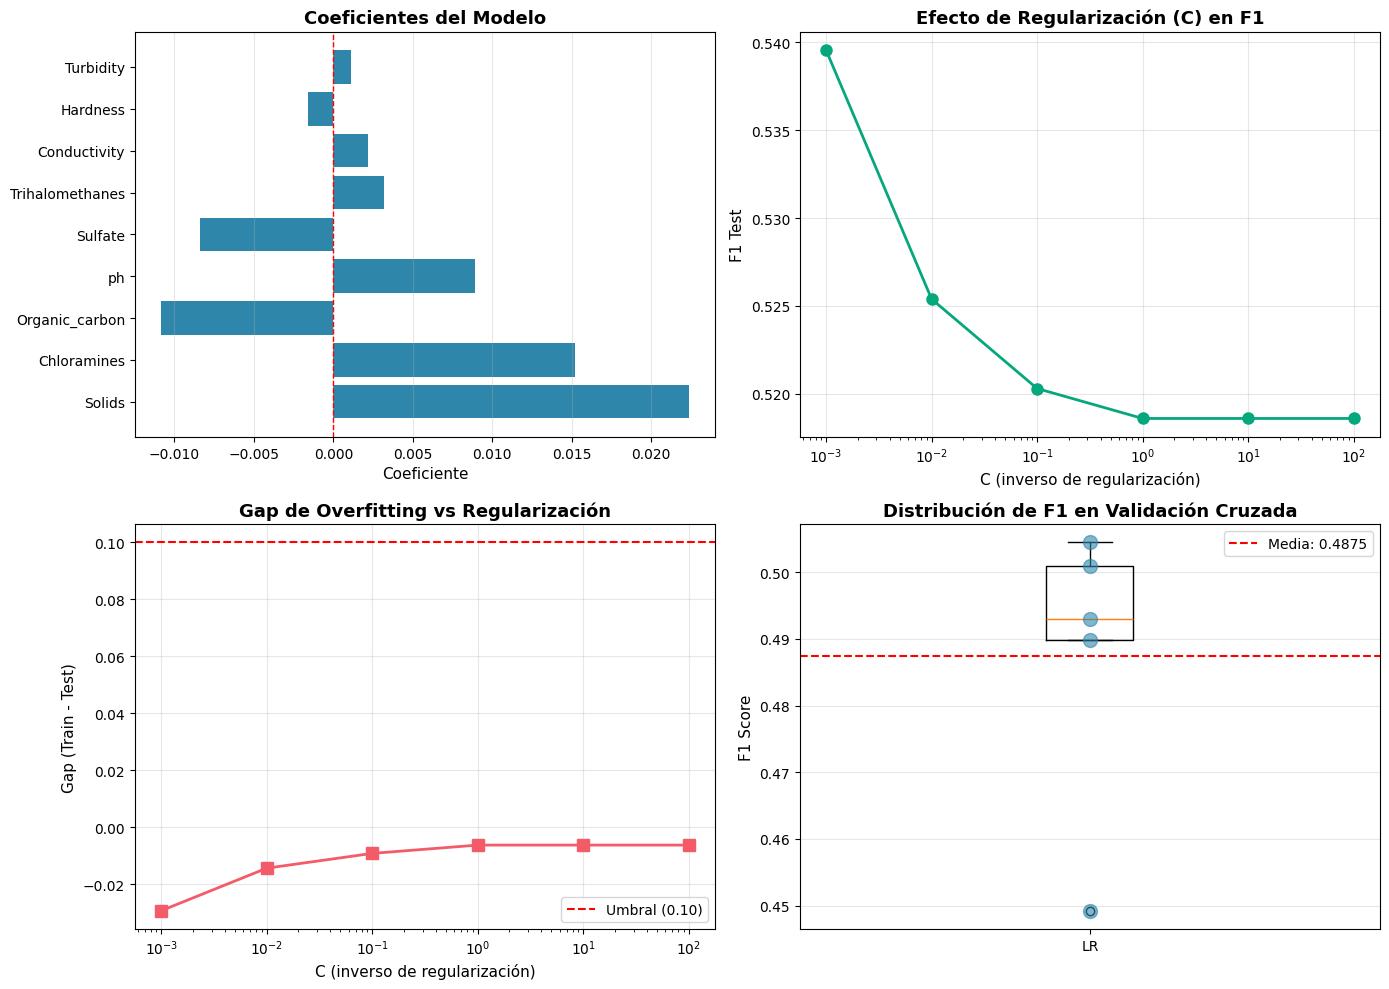

In [2]:
import polars as pl
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import joblib
import matplotlib.pyplot as plt

# 1. Cargar datos
df = pl.read_csv("../data/raw_drinking_water_potability.csv")

numeric_cols = df.columns[:-1]
X = df.select(numeric_cols).to_numpy()
y = df["Potability"].to_numpy()

print("="*70)
print("📈 REGRESIÓN LOGÍSTICA - Evitando Overfitting")
print("="*70)

# 2. Split PRIMERO (evitar data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Preprocesamiento (IMPORTANTE para Regresión Logística)
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()  # CRÍTICO: Regresión Logística necesita escalado

X_train_prep = scaler.fit_transform(imputer.fit_transform(X_train))
X_test_prep = scaler.transform(imputer.transform(X_test))

print(f"\n📊 Datos preparados:")
print(f"   Train: {X_train_prep.shape}")
print(f"   Test:  {X_test_prep.shape}")

# ============================================================================
# EXPERIMENTO 1: Diferentes configuraciones de regularización
# ============================================================================
print("\n" + "="*70)
print("1️⃣  EXPERIMENTO 1: Diferentes niveles de regularización (C)")
print("="*70)

print("\nNota: C es el inverso de la regularización")
print("   • C bajo (ej: 0.01) = Regularización FUERTE → Menos overfitting")
print("   • C alto (ej: 100)  = Regularización DÉBIL → Más overfitting")

C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
results = {}

for C in C_values:
    lr = LogisticRegression(
        C=C,
        penalty='l2',
        solver='lbfgs',
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )
    
    lr.fit(X_train_prep, y_train)
    
    y_train_pred = lr.predict(X_train_prep)
    y_test_pred = lr.predict(X_test_prep)
    
    train_f1 = f1_score(y_train, y_train_pred, average='macro')
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    gap = train_f1 - test_f1
    
    results[C] = {
        'train_f1': train_f1,
        'test_f1': test_f1,
        'gap': gap,
        'model': lr
    }
    
    status = "✅" if gap < 0.10 else "⚠️"
    print(f"{status} C={C:>7.3f} | F1 Test: {test_f1:.4f} | Gap: {gap:.4f}")

# ============================================================================
# EXPERIMENTO 2: Diferentes tipos de penalización
# ============================================================================
print("\n" + "="*70)
print("2️⃣  EXPERIMENTO 2: Tipos de penalización")
print("="*70)

print("\nNota sobre penalizaciones:")
print("   • L2 (Ridge):     Reduce todos los coeficientes proporcionalmente")
print("   • L1 (Lasso):     Puede llevar coeficientes a exactamente 0")
print("   • Elasticnet:     Combinación de L1 y L2")

penalties = [
    {'penalty': 'l2', 'solver': 'lbfgs', 'C': 1.0},
    {'penalty': 'l1', 'solver': 'saga', 'C': 1.0},
    {'penalty': 'elasticnet', 'solver': 'saga', 'C': 1.0, 'l1_ratio': 0.5},
]

penalty_results = {}

for config in penalties:
    penalty_name = config['penalty']
    
    lr = LogisticRegression(
        penalty=config['penalty'],
        solver=config['solver'],
        C=config['C'],
        l1_ratio=config.get('l1_ratio'),
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )
    
    lr.fit(X_train_prep, y_train)
    
    y_train_pred = lr.predict(X_train_prep)
    y_test_pred = lr.predict(X_test_prep)
    
    train_f1 = f1_score(y_train, y_train_pred, average='macro')
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    gap = train_f1 - test_f1
    
    penalty_results[penalty_name] = {
        'train_f1': train_f1,
        'test_f1': test_f1,
        'gap': gap,
        'model': lr
    }
    
    status = "✅" if gap < 0.10 else "⚠️"
    print(f"{status} {penalty_name:12s} | F1 Test: {test_f1:.4f} | Gap: {gap:.4f}")

# ============================================================================
# EXPERIMENTO 3: Grid Search exhaustivo
# ============================================================================
print("\n" + "="*70)
print("3️⃣  EXPERIMENTO 3: Grid Search con validación cruzada")
print("="*70)

param_grid = {
    'C': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'max_iter': [1000]
}

lr_grid = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    lr_grid,
    param_grid,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("\n🔄 Buscando mejores hiperparámetros...")
grid_search.fit(X_train_prep, y_train)

print(f"\n✅ Mejores hiperparámetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f"   • {param}: {value}")

print(f"\n📊 F1 Score en CV: {grid_search.best_score_:.4f}")

# Evaluar en test
y_pred_grid = grid_search.best_estimator_.predict(X_test_prep)
test_f1_grid = f1_score(y_test, y_pred_grid, average='macro')

y_train_pred_grid = grid_search.best_estimator_.predict(X_train_prep)
train_f1_grid = f1_score(y_train, y_train_pred_grid, average='macro')
gap_grid = train_f1_grid - test_f1_grid

print(f"📊 F1 Test: {test_f1_grid:.4f}")
print(f"📊 Gap: {gap_grid:.4f}")

if gap_grid < 0.10:
    print("   ✅ Excelente generalización (gap < 0.10)")
elif gap_grid < 0.15:
    print("   ✅ Buena generalización (gap < 0.15)")
else:
    print("   ⚠️  Posible overfitting (gap ≥ 0.15)")

# ============================================================================
# EXPERIMENTO 4: Análisis de overfitting
# ============================================================================
print("\n" + "="*70)
print("4️⃣  EXPERIMENTO 4: Análisis de overfitting por configuración")
print("="*70)

import pandas as pd

results_df = pd.DataFrame(grid_search.cv_results_)
results_df['overfitting_gap'] = results_df['mean_train_score'] - results_df['mean_test_score']

# Top 5 con mejor F1
print("\n🏆 Top 5 configuraciones por F1 Test:")
top_f1 = results_df.nlargest(5, 'mean_test_score')[
    ['params', 'mean_train_score', 'mean_test_score', 'overfitting_gap']
]

for idx, row in top_f1.iterrows():
    print(f"\n   Configuración {idx}:")
    print(f"   C = {row['params']['C']}")
    print(f"   Train F1: {row['mean_train_score']:.4f}")
    print(f"   CV F1:    {row['mean_test_score']:.4f}")
    print(f"   Gap:      {row['overfitting_gap']:.4f}")

# Configuraciones con buen balance
good_generalization = results_df[results_df['overfitting_gap'] < 0.10]

if len(good_generalization) > 0:
    print(f"\n✅ Encontradas {len(good_generalization)} configuraciones con gap < 0.10")
    
    # Mejor entre los que generalizan bien
    best_balanced_idx = good_generalization['mean_test_score'].idxmax()
    best_balanced = results_df.loc[best_balanced_idx]
    
    print(f"\n🎯 Configuración con mejor balance (gap < 0.10 y mejor F1):")
    print(f"   C = {best_balanced['params']['C']}")
    print(f"   F1 CV: {best_balanced['mean_test_score']:.4f}")
    print(f"   Gap: {best_balanced['overfitting_gap']:.4f}")
else:
    print("\n⚠️  Todas las configuraciones tienen gap ≥ 0.10")

# ============================================================================
# EXPERIMENTO 5: Coeficientes del modelo (interpretabilidad)
# ============================================================================
print("\n" + "="*70)
print("5️⃣  EXPERIMENTO 5: Coeficientes del modelo")
print("="*70)

best_lr = grid_search.best_estimator_
coefficients = best_lr.coef_[0]
feature_names = numeric_cols

# Ordenar por valor absoluto (importancia)
abs_coef = np.abs(coefficients)
indices = np.argsort(abs_coef)[::-1]

print("\n📊 Coeficientes ordenados por importancia (valor absoluto):")
print("   Nota: + indica correlación positiva con potabilidad")
print("         - indica correlación negativa con potabilidad\n")

for i, idx in enumerate(indices, 1):
    coef = coefficients[idx]
    sign = "+" if coef > 0 else "-"
    bar = '█' * int(abs(coef) * 10)
    print(f"   {i}. {feature_names[idx]:20s}: {sign}{abs(coef):>6.4f} {bar}")

print(f"\n   Intercept (sesgo): {best_lr.intercept_[0]:.4f}")

# ============================================================================
# VALIDACIÓN CRUZADA COMPLETA
# ============================================================================
print("\n" + "="*70)
print("6️⃣  VALIDACIÓN CRUZADA (5-fold)")
print("="*70)

cv_scores = cross_val_score(
    grid_search.best_estimator_,
    X_train_prep,
    y_train,
    cv=cv_strategy,
    scoring='f1_macro'
)

print(f"\nF1 scores por fold:")
for i, score in enumerate(cv_scores, 1):
    print(f"   Fold {i}: {score:.4f}")

print(f"\nF1 promedio: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# ============================================================================
# MODELO FINAL - EVALUACIÓN
# ============================================================================
print("\n" + "="*70)
print("7️⃣  EVALUACIÓN FINAL DEL MODELO OPTIMIZADO")
print("="*70)

# Usar el mejor modelo del grid search
final_model = grid_search.best_estimator_

# Predicciones finales
y_train_pred_final = final_model.predict(X_train_prep)
y_test_pred_final = final_model.predict(X_test_prep)

train_f1_final = f1_score(y_train, y_train_pred_final, average='macro')
test_f1_final = f1_score(y_test, y_test_pred_final, average='macro')
gap_final = train_f1_final - test_f1_final

print(f"\n🎯 Performance del modelo final:")
print(f"   F1 Train:  {train_f1_final:.4f}")
print(f"   F1 CV:     {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"   F1 Test:   {test_f1_final:.4f}")
print(f"   Gap:       {gap_final:.4f}")

if gap_final < 0.05:
    status = "✅ EXCELENTE generalización"
elif gap_final < 0.10:
    status = "✅ MUY BUENA generalización"
elif gap_final < 0.15:
    status = "✅ BUENA generalización"
else:
    status = "⚠️ Posible overfitting"

print(f"\n   {status}")

# ============================================================================
# REPORTE DE CLASIFICACIÓN
# ============================================================================
print("\n" + "="*70)
print("📊 REPORTE DE EVALUACIÓN - REGRESIÓN LOGÍSTICA")
print("="*70)

print(f"\nF1 Test: {test_f1_final}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_final))

print(classification_report(
    y_test, 
    y_test_pred_final, 
    target_names=['No Potable', 'Potable'],
    digits=2
))

# ============================================================================
# VISUALIZACIONES
# ============================================================================
print("\n" + "="*70)
print("📈 GENERANDO VISUALIZACIONES")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Coeficientes del modelo
axes[0, 0].barh(range(len(feature_names)), coefficients[indices], color='#2E86AB')
axes[0, 0].set_yticks(range(len(feature_names)))
axes[0, 0].set_yticklabels([feature_names[i] for i in indices])
axes[0, 0].set_xlabel('Coeficiente', fontsize=11)
axes[0, 0].set_title('Coeficientes del Modelo', fontsize=13, fontweight='bold')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2. Efecto de C en F1 Test
C_vals = list(results.keys())
f1_vals = [results[c]['test_f1'] for c in C_vals]
gap_vals = [results[c]['gap'] for c in C_vals]

axes[0, 1].semilogx(C_vals, f1_vals, marker='o', linewidth=2, markersize=8, color='#06A77D')
axes[0, 1].set_xlabel('C (inverso de regularización)', fontsize=11)
axes[0, 1].set_ylabel('F1 Test', fontsize=11)
axes[0, 1].set_title('Efecto de Regularización (C) en F1', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Gap de overfitting por valor de C
axes[1, 0].semilogx(C_vals, gap_vals, marker='s', linewidth=2, markersize=8, color='#F45B69')
axes[1, 0].axhline(y=0.10, color='red', linestyle='--', label='Umbral (0.10)')
axes[1, 0].set_xlabel('C (inverso de regularización)', fontsize=11)
axes[1, 0].set_ylabel('Gap (Train - Test)', fontsize=11)
axes[1, 0].set_title('Gap de Overfitting vs Regularización', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# 4. Scores de validación cruzada
axes[1, 1].boxplot([cv_scores], labels=['LR'])
axes[1, 1].scatter([1]*len(cv_scores), cv_scores, color='#2E86AB', s=100, alpha=0.6, zorder=3)
axes[1, 1].axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Media: {cv_scores.mean():.4f}')
axes[1, 1].set_ylabel('F1 Score', fontsize=11)
axes[1, 1].set_title('Distribución de F1 en Validación Cruzada', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('logistic_regression_analysis.png', dpi=300, bbox_inches='tight')
print("\n✅ Gráfica guardada: 'logistic_regression_analysis.png'")

# ============================================================================
# GUARDAR MODELO
# ============================================================================
print("\n" + "="*70)
print("💾 GUARDANDO MODELO")
print("="*70)

joblib.dump(final_model, 'modelo_lr_final.pkl')
joblib.dump(imputer, 'imputer_lr_final.pkl')
joblib.dump(scaler, 'scaler_lr_final.pkl')

print("\n✅ Archivos guardados:")
print("   • modelo_lr_final.pkl")
print("   • imputer_lr_final.pkl")
print("   • scaler_lr_final.pkl")

# ============================================================================
# RESUMEN EJECUTIVO
# ============================================================================
print("\n" + "="*70)
print("✨ RESUMEN EJECUTIVO - REGRESIÓN LOGÍSTICA")
print("="*70)

print(f"""
📊 PERFORMANCE FINAL:
   • F1 Test:  {test_f1_final:.4f}
   • F1 Train: {train_f1_final:.4f}
   • F1 CV:    {cv_scores.mean():.4f} ± {cv_scores.std():.4f}
   • Gap:      {gap_final:.4f} → {status}

⚙️ CONFIGURACIÓN ÓPTIMA:
   • C (regularización):  {final_model.C}
   • Penalty:             {final_model.penalty}
   • Solver:              {final_model.solver}
   • Class weight:        balanced
   • Max iterations:      {final_model.max_iter}

📈 TOP 3 FEATURES MÁS INFLUYENTES:
   1. {feature_names[indices[0]]}: {coefficients[indices[0]]:+.4f}
   2. {feature_names[indices[1]]}: {coefficients[indices[1]]:+.4f}
   3. {feature_names[indices[2]]}: {coefficients[indices[2]]:+.4f}

✅ TÉCNICAS ANTI-OVERFITTING APLICADAS:
   1. Regularización L2 (Ridge)
   2. Validación cruzada estratificada (5-fold)
   3. Grid search exhaustivo con CV
   4. Class weighting para desbalance
   5. Escalado de features (StandardScaler)
   6. Preprocesamiento sin data leakage

✨ VENTAJAS DE REGRESIÓN LOGÍSTICA:
   • Simple y rápida de entrenar
   • Altamente interpretable (coeficientes)
   • Buen baseline para problemas de clasificación
   • Probabilidades calibradas
   • Poco propensa a overfitting
""")

print("\n💡 USO EN PRODUCCIÓN:")
print("""
import joblib

# Cargar modelo
modelo = joblib.load('modelo_lr_final.pkl')
imputer = joblib.load('imputer_lr_final.pkl')
scaler = joblib.load('scaler_lr_final.pkl')

# Predecir nuevos datos
X_new_prep = scaler.transform(imputer.transform(X_new))
prediccion = modelo.predict(X_new_prep)
probabilidad = modelo.predict_proba(X_new_prep)

# Interpretar: coeficientes muestran el impacto de cada feature
print(f"Coeficientes: {modelo.coef_[0]}")
""")

print("\n" + "="*70)
print("🎉 ¡REGRESIÓN LOGÍSTICA OPTIMIZADA COMPLETADA!")
print("="*70)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt

# --- Carga de datos ---
df = pd.read_csv("../data/raw_drinking_water_potability.csv")

X = df.drop(columns="Potability").to_numpy()
y = df["Potability"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Pipeline de preprocesamiento + modelo ---
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

# --- GridSearchCV ---
param_grid = {
    "clf__C": [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs"],
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="f1_macro",
    n_jobs=-1,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

# --- Mejor modelo ---
best_model = grid_search.best_estimator_
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_f1 = f1_score(y_train, y_train_pred, average="macro")
test_f1 = f1_score(y_test, y_test_pred, average="macro")

print("Train F1:", round(train_f1, 3))
print("Test F1:", round(test_f1, 3))
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred, target_names=["No Potable", "Potable"], digits=2))

# --- Coeficientes de importancia ---
coefficients = best_model.named_steps["clf"].coef_[0]
feature_names = df.drop(columns="Potability").columns
abs_coef = np.abs(coefficients)
indices = np.argsort(abs_coef)[::-1]

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_names)), coefficients[indices])
plt.yticks(range(len(feature_names)), [feature_names[i] for i in indices])
plt.axvline(x=0, linestyle="--", color="k")
plt.grid(True, axis="x")
plt.title("Importancia de coeficientes de Logistic Regression")
plt.tight_layout()
plt.savefig("feature_importance_lr.png", dpi=300)
plt.close()

# --- Cross-validation scores ---
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv_strategy, scoring="f1_macro")
print("CV F1 scores:", cv_scores)
print("Mean CV F1:", round(cv_scores.mean(), 3))

# --- Persistencia ---
#joblib.dump(best_model, "pipeline_lr_final.pkl")
